In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold , GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, r2_score, mean_squared_error, ConfusionMatrixDisplay, classification_report, roc_curve, auc
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model

## linear 

In [60]:
df_lin = pd.read_csv('House Price India.csv')
print(df_lin.info())
print(df_lin.describe())
corr = df_lin.corr()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14619 entries, 0 to 14618
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14619 non-null  int64  
 1   Date                                   14619 non-null  int64  
 2   number of bedrooms                     14619 non-null  int64  
 3   number of bathrooms                    14619 non-null  float64
 4   living area                            14619 non-null  int64  
 5   lot area                               14619 non-null  int64  
 6   number of floors                       14619 non-null  float64
 7   waterfront present                     14619 non-null  int64  
 8   number of views                        14619 non-null  int64  
 9   condition of the house                 14619 non-null  int64  
 10  grade of the house                     14619 non-null  int64  
 11  Ar

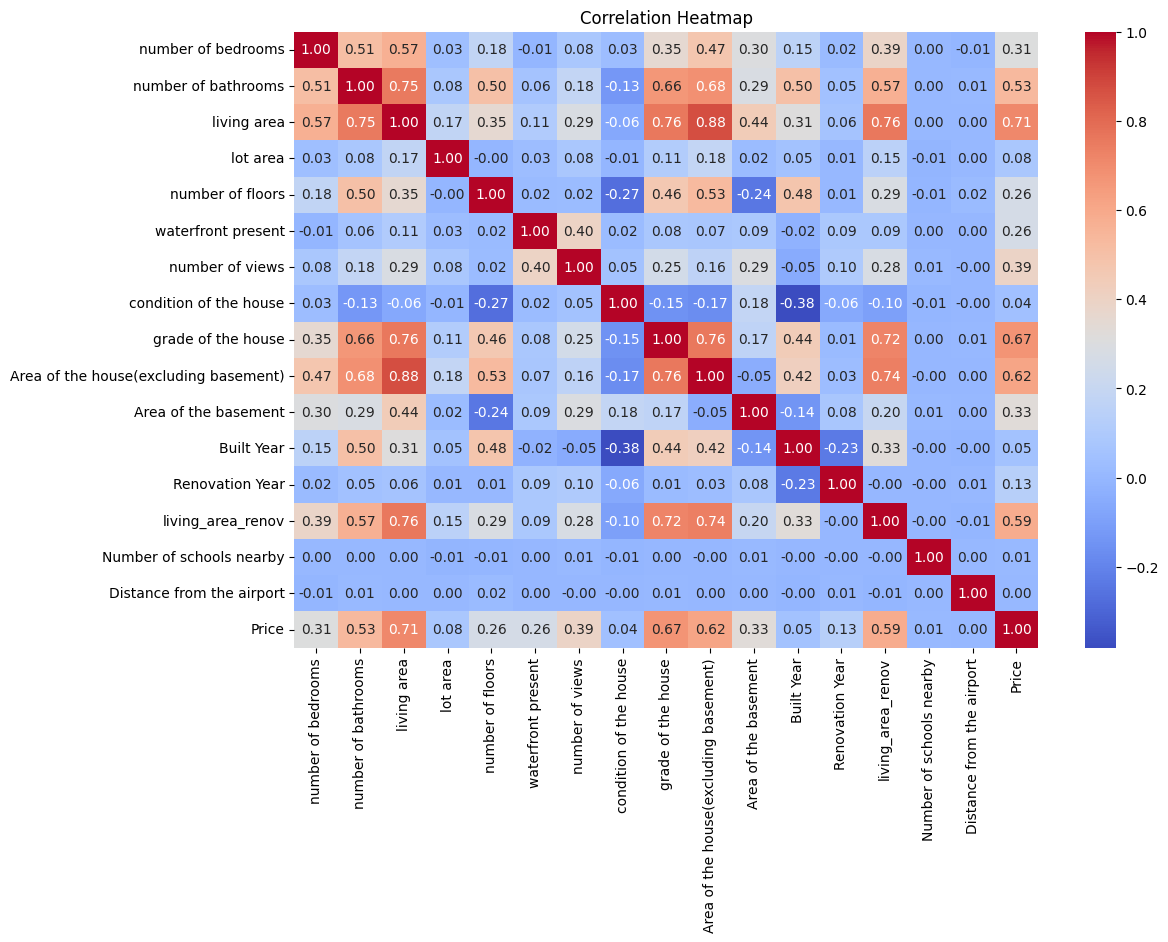

In [61]:
df_1 = df_lin.drop(['id', 'Date', 'Postal Code', 'Lattitude', 'Longitude',  'lot_area_renov'], axis=1)
corr = df_1.corr()


plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [62]:
top_features = corr['Price'].sort_values(ascending=False).index[1:6]
print(f"{top_features}")


used_col = top_features


def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]


for col in used_col:
    cleaned_df = remove_outliers(df_1, col)

Index(['living area', 'grade of the house',
       'Area of the house(excluding basement)', 'living_area_renov',
       'number of bathrooms'],
      dtype='object')


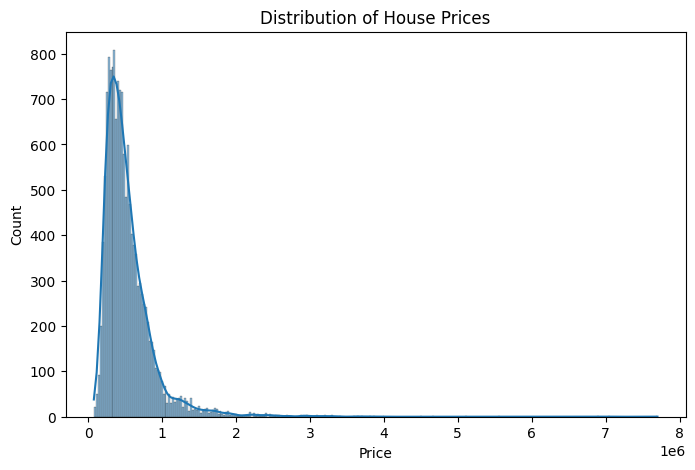

In [63]:

corr = df_lin.drop(columns=['id', 'Date', 'Postal Code']).corr()






plt.figure(figsize=(8,5))
sns.histplot(df_lin['Price'], kde=True)
plt.title('Distribution of House Prices')
plt.show()

In [64]:
X = df_1.drop('Price', axis=1)
y = df_1['Price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Simple Linear Regression

Most correlated feature with Price: living area
Simple Linear Regression (using living area)
R²: 0.5323
MSE: 69220882498.21


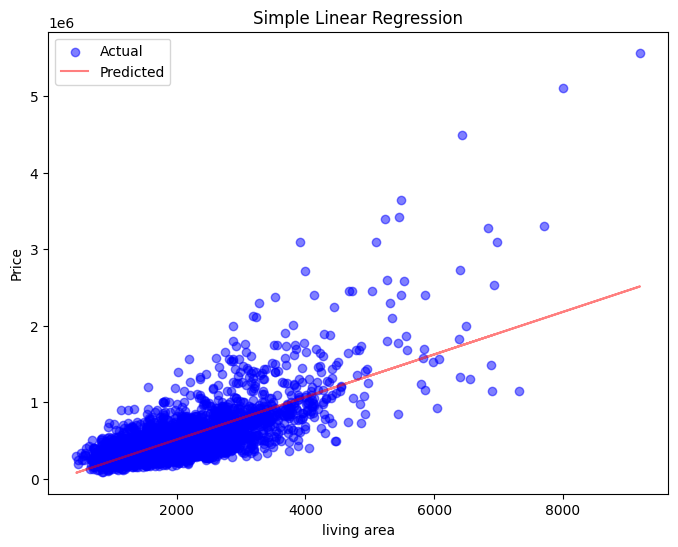

In [65]:

most_correlated_feature = corr['Price'].sort_values(ascending=False).index[1]
print(f"Most correlated feature with Price: {most_correlated_feature}")


X_train_single = X_train[[most_correlated_feature]]
X_test_single = X_test[[most_correlated_feature]]

lr_simple = LinearRegression()
lr_simple.fit(X_train_single, y_train)
y_pred_simple = lr_simple.predict(X_test_single)


r2_simple = r2_score(y_test, y_pred_simple)
mse_simple = mean_squared_error(y_test, y_pred_simple)
print(f"Simple Linear Regression (using {most_correlated_feature})")
print(f"R²: {r2_simple:.4f}")
print(f"MSE: {mse_simple:.2f}")


plt.figure(figsize=(8,6))
plt.scatter(X_test_single, y_test, color='blue', alpha=0.5, label='Actual')
plt.plot(X_test_single, y_pred_simple, color='red', alpha=0.5,  label='Predicted')
plt.xlabel(most_correlated_feature)
plt.ylabel('Price')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

#### Multiple Linear Regression

In [66]:
X_train_multi = X_train[top_features]
X_test_multi = X_test[top_features]

lr_multi = LinearRegression()
lr_multi.fit(X_train_multi, y_train)
y_pred_multi = lr_multi.predict(X_test_multi)


r2_multi = r2_score(y_test, y_pred_multi)
mse_multi = mean_squared_error(y_test, y_pred_multi)
print("\nMultiple Linear Regression (using top 5 features)")
print(f"R²: {r2_multi:.4f}")
print(f"MSE: {mse_multi:.2f}")


print(f"\nImprovement in R²: {(r2_multi - r2_simple):.4f}")
print(f"Improvement in MSE: {(mse_simple - mse_multi):.2f}")


Multiple Linear Regression (using top 5 features)
R²: 0.5714
MSE: 63432424535.26

Improvement in R²: 0.0391
Improvement in MSE: 5788457962.95


#### Polynomial Regression

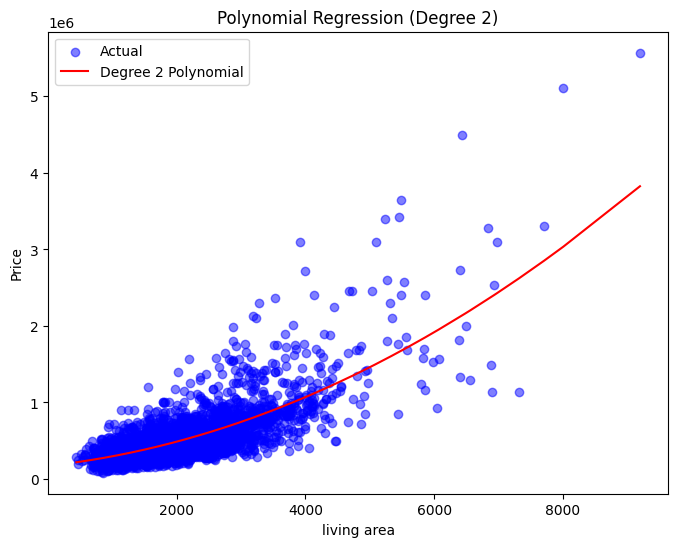

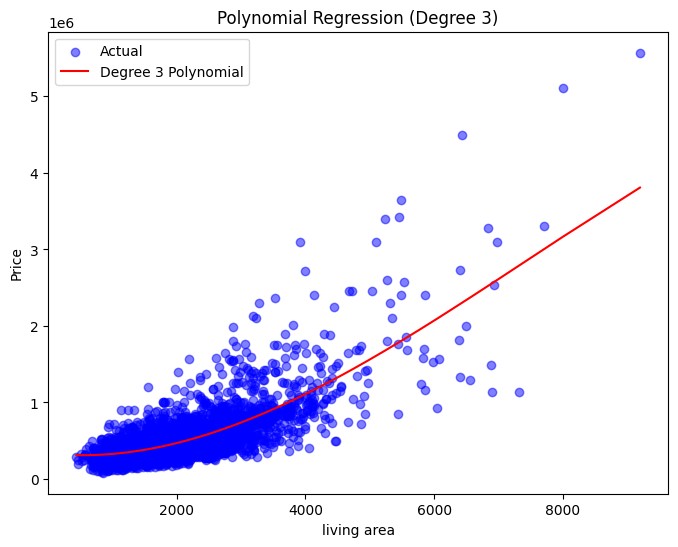

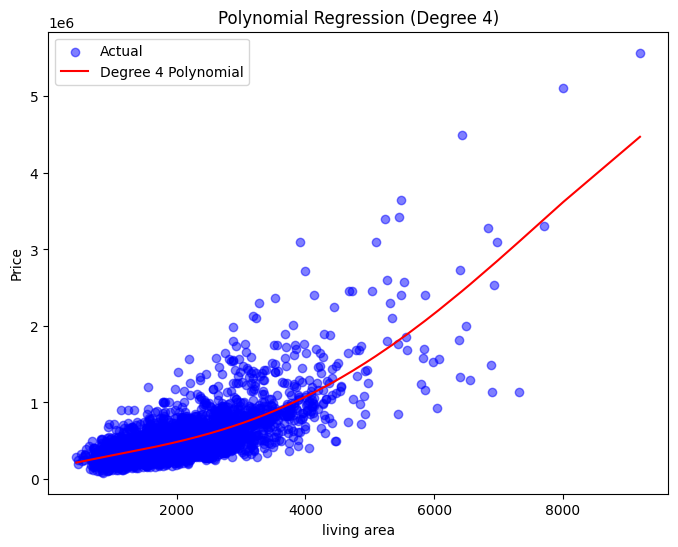


Polynomial Regression Results:
Degree	R²		MSE
2	0.5847	61458586473.80
3	0.5884	60912300768.75
4	0.5897	60721443095.13


In [67]:

X_train_poly = X_train_single.values.reshape(-1,1)
X_test_poly = X_test_single.values.reshape(-1,1)

degrees = [2, 3, 4]
results = []

for degree in degrees:
    
    poly = PolynomialFeatures(degree=degree)
    X_train_poly_feat = poly.fit_transform(X_train_poly)
    X_test_poly_feat = poly.transform(X_test_poly)
    
    
    scaler_poly = StandardScaler()
    X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly_feat)
    X_test_poly_scaled = scaler_poly.transform(X_test_poly_feat)
    
    
    lr_poly = LinearRegression()
    lr_poly.fit(X_train_poly_scaled, y_train)
    y_pred_poly = lr_poly.predict(X_test_poly_scaled)
    
    
    r2_poly = r2_score(y_test, y_pred_poly)
    mse_poly = mean_squared_error(y_test, y_pred_poly)
    results.append((degree, r2_poly, mse_poly))
    
    
    plt.figure(figsize=(8,6))
    plt.scatter(X_test_poly, y_test, color='blue', alpha=0.5, label='Actual')
    
    
    sorted_idx = np.argsort(X_test_poly.ravel())
    plt.plot(X_test_poly[sorted_idx], y_pred_poly[sorted_idx], color='red', 
             label=f'Degree {degree} Polynomial')
    
    plt.xlabel(most_correlated_feature)
    plt.ylabel('Price')
    plt.title(f'Polynomial Regression (Degree {degree})')
    plt.legend()
    plt.show()


print("\nPolynomial Regression Results:")
print("Degree\tR²\t\tMSE")
for degree, r2, mse in results:
    print(f"{degree}\t{r2:.4f}\t{mse:.2f}")

## logistic

In [68]:
df = pd.read_csv('data.csv')

df.drop(columns=['id', 'Unnamed: 32'], inplace=True)

df['diagnosis'] = LabelEncoder().fit_transform(df['diagnosis'])

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [69]:
df.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [70]:
X_b = df.drop(columns='diagnosis')
y_b = df['diagnosis']

X_train_b, X_temp_b, y_train_b, y_temp_b = train_test_split(X_b, y_b, train_size=0.6, stratify=y_b, random_state=42)

X_val_b, X_test_b, y_val_b, y_test_b = train_test_split(X_temp_b, y_temp_b, test_size=0.5, stratify=y_temp_b, random_state=42)


In [71]:
scaler = StandardScaler()
X_train_scaled_b = scaler.fit_transform(X_train_b)
X_test_scaled_b = scaler.transform(X_test_b)

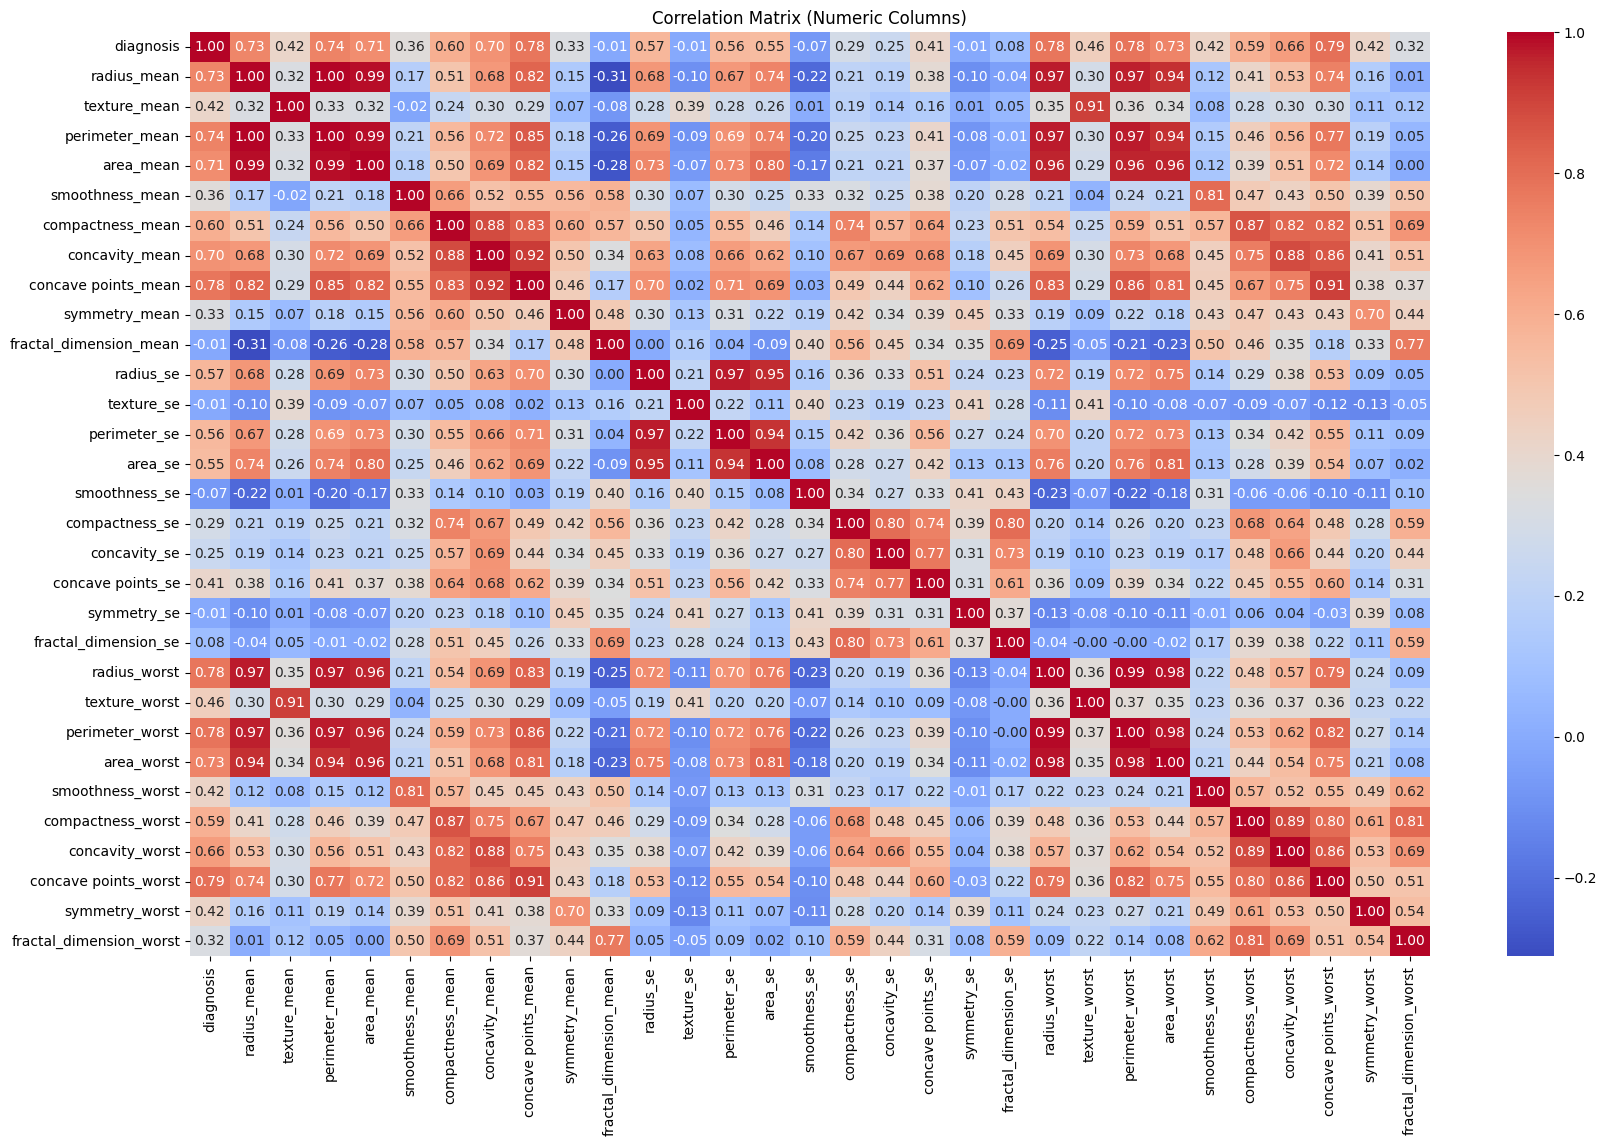

In [72]:
plt.figure(figsize=(20, 12))
sns.heatmap(df.select_dtypes(include=['number']).corr(),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (Numeric Columns)")
plt.show()

In [73]:
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled_b, y_train_b)
y_pred_b= log_reg.predict(X_test_scaled_b)

log_accuracy = accuracy_score(y_test_b, y_pred_b)

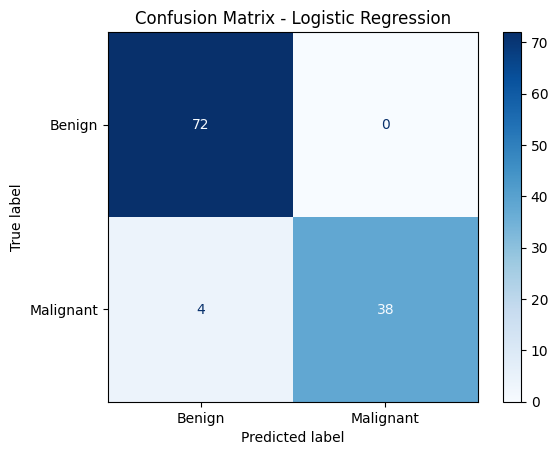

In [74]:
# Generate confusion matrix
cm = confusion_matrix(y_test_b, y_pred_b)

# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

#### KNN Model

In [ ]:
X_train_val = pd.concat([X_train_b, X_val_b])
y_train_val = pd.concat([y_train_b, y_val_b])

knn_final = KNeighborsClassifier(n_neighbors=7)
knn_final.fit(X_train_val, y_train_val)

y_test_pred = knn_final.predict(X_test_b)

knn_accuracy = accuracy_score(y_test_b, y_test_pred)
precision = precision_score(y_test_b, y_test_pred)
recall = recall_score(y_test_b, y_test_pred)
f1 = f1_score(y_test_b, y_test_pred)
conf_matrix = confusion_matrix(y_test_b, y_test_pred)



## Cross Validation

In [77]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(KNeighborsClassifier(n_neighbors=best_k), X_train_b, y_train_b, cv=cv)
cv_mean_accuracy = np.mean(cv_scores)

print("5-Fold Cross-Validation Mean Accuracy:", cv_mean_accuracy)


5-Fold Cross-Validation Mean Accuracy: 0.9179880647911338


## Confusion Matrix Heatmap


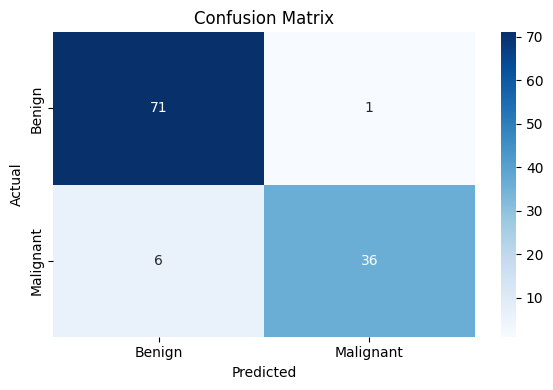

In [78]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


#### SVM

In [79]:
kernels = ['linear', 'poly', 'rbf']
svm_results = {}

for kernel in kernels:
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_train_scaled_b, y_train_b)
    y_predict = svm.predict(X_test_scaled_b)
    
    acc = accuracy_score(y_test_b, y_predict)
    cm = confusion_matrix(y_test_b, y_predict)
    report = classification_report(y_test_b, y_predict, output_dict=True)
    
    svm_results[kernel] = {
        "accuracy": acc,
        "confusion_matrix": cm,
        "classification_report": report
    }

svm_results


{'linear': {'accuracy': 0.956140350877193,
  'confusion_matrix': array([[72,  0],
         [ 5, 37]]),
  'classification_report': {'0': {'precision': 0.935064935064935,
    'recall': 1.0,
    'f1-score': 0.9664429530201343,
    'support': 72.0},
   '1': {'precision': 1.0,
    'recall': 0.8809523809523809,
    'f1-score': 0.9367088607594937,
    'support': 42.0},
   'accuracy': 0.956140350877193,
   'macro avg': {'precision': 0.9675324675324675,
    'recall': 0.9404761904761905,
    'f1-score': 0.951575906889814,
    'support': 114.0},
   'weighted avg': {'precision': 0.9589883800410116,
    'recall': 0.956140350877193,
    'f1-score': 0.9554882874504246,
    'support': 114.0}}},
 'poly': {'accuracy': 0.8771929824561403,
  'confusion_matrix': array([[72,  0],
         [14, 28]]),
  'classification_report': {'0': {'precision': 0.8372093023255814,
    'recall': 1.0,
    'f1-score': 0.9113924050632911,
    'support': 72.0},
   '1': {'precision': 1.0,
    'recall': 0.6666666666666666,
    '

#### Neural Network

Epoch 1/50


c:\Users\Cool\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5168 - loss: 0.7854 - val_accuracy: 0.7719 - val_loss: 0.5446
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7748 - loss: 0.5102 - val_accuracy: 0.8947 - val_loss: 0.3594
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8939 - loss: 0.3363 - val_accuracy: 0.9298 - val_loss: 0.2579
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9368 - loss: 0.2486 - val_accuracy: 0.9386 - val_loss: 0.2026
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9732 - loss: 0.1749 - val_accuracy: 0.9474 - val_loss: 0.1688
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9628 - loss: 0.1544 - val_accuracy: 0.9561 - val_loss: 0.1459
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9626 - loss: 0.1279 - val_accuracy: 0.9649 - val_loss: 0.1315
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9541 - loss: 0.1412 - val_accuracy: 0.9649 - val_loss: 0.1209
Ep

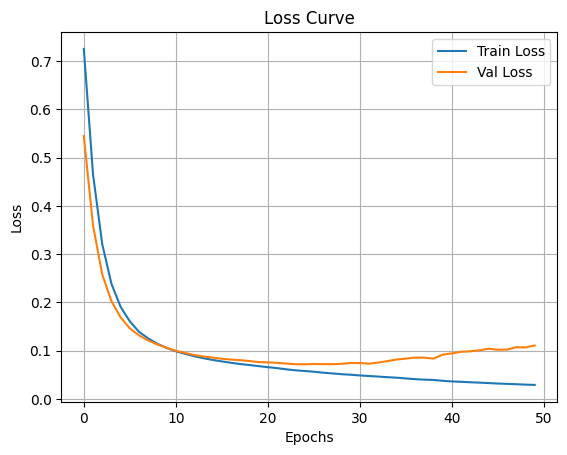

In [80]:
model = Sequential([
    Dense(16, input_shape=(X_train_scaled_b.shape[1],), activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')  
])


model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])


history = model.fit(X_train_scaled_b, y_train_b, epochs=50, batch_size=16,
                    validation_data=(X_test_scaled_b, y_test_b), verbose=1)


y_pred_probs = model.predict(X_test_scaled_b)
nn_y_pred = (y_pred_probs > 0.5).astype("int32")


acc = accuracy_score(y_test_b, y_predict)
cm = confusion_matrix(y_test_b, y_predict)
report = classification_report(y_test_b, y_predict)

print(f"Accuracy: {acc:.4f}")
print("Confusion Matrix:")
print(cm)
print("Classification Report:")
print(report)

# Plot loss curve
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


#### Model Comparison

In [81]:
nn_acc = accuracy_score(y_test_b, nn_y_pred)
nn_report = classification_report(y_test_b, nn_y_pred, output_dict=True)
lr_report = classification_report(y_test_b, y_pred_b, output_dict=True)
knn_report = classification_report(y_test_b, y_test_pred, output_dict=True)


comparison_df = pd.DataFrame({
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1-score": []
})


for kernel in kernels:
    report = svm_results[kernel]["classification_report"]
    comparison_df = pd.concat([comparison_df, pd.DataFrame({
        "Model": [f"SVM ({kernel})"],
        "Accuracy": [svm_results[kernel]["accuracy"]],
        "Precision": [report['1']['precision']],
        "Recall": [report['1']['recall']],
        "F1-score": [report['1']['f1-score']]
    })], ignore_index=True)


comparison_df = pd.concat([comparison_df, pd.DataFrame({
    "Model": ["Neural Network"],
    "Accuracy": [nn_acc],
    "Precision": [nn_report['1']['precision']],
    "Recall": [nn_report['1']['recall']],
    "F1-score": [nn_report['1']['f1-score']]
})], ignore_index=True)


comparison_df = pd.concat([comparison_df, pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [log_accuracy],
    "Precision": [lr_report['1']['precision']],
    "Recall": [lr_report['1']['recall']],
    "F1-score": [lr_report['1']['f1-score']]
})], ignore_index=True)


comparison_df = pd.concat([comparison_df, pd.DataFrame({
    "Model": ["K-Nearest Neighbors"],
    "Accuracy": [knn_accuracy],
    "Precision": [knn_report['1']['precision']],
    "Recall": [knn_report['1']['recall']],
    "F1-score": [knn_report['1']['f1-score']]
})], ignore_index=True)


print(comparison_df)



                 Model  Accuracy  Precision    Recall  F1-score
0         SVM (linear)  0.956140   1.000000  0.880952  0.936709
1           SVM (poly)  0.877193   1.000000  0.666667  0.800000
2            SVM (rbf)  0.982456   1.000000  0.952381  0.975610
3       Neural Network  0.973684   1.000000  0.928571  0.962963
4  Logistic Regression  0.964912   1.000000  0.904762  0.950000
5  K-Nearest Neighbors  0.938596   0.972973  0.857143  0.911392


In [82]:

svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}
svm_grid = GridSearchCV(SVC(), svm_params, cv=2, scoring='accuracy')
svm_grid.fit(X_train_scaled_b, y_train_b)
best_svm = svm_grid.best_estimator_
print("Best SVM Parameters:", svm_grid.best_params_)


lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000), lr_params, cv=2, scoring='accuracy')
lr_grid.fit(X_train_scaled_b, y_train_b)
best_lr = lr_grid.best_estimator_
print("Best Logistic Regression Parameters:", lr_grid.best_params_)


knn_params = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=2, scoring='accuracy')
knn_grid.fit(X_train_scaled_b, y_train_b)
best_knn = knn_grid.best_estimator_
print("Best KNN Parameters:", knn_grid.best_params_)

Best SVM Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best Logistic Regression Parameters: {'C': 1, 'solver': 'lbfgs'}
Best KNN Parameters: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}


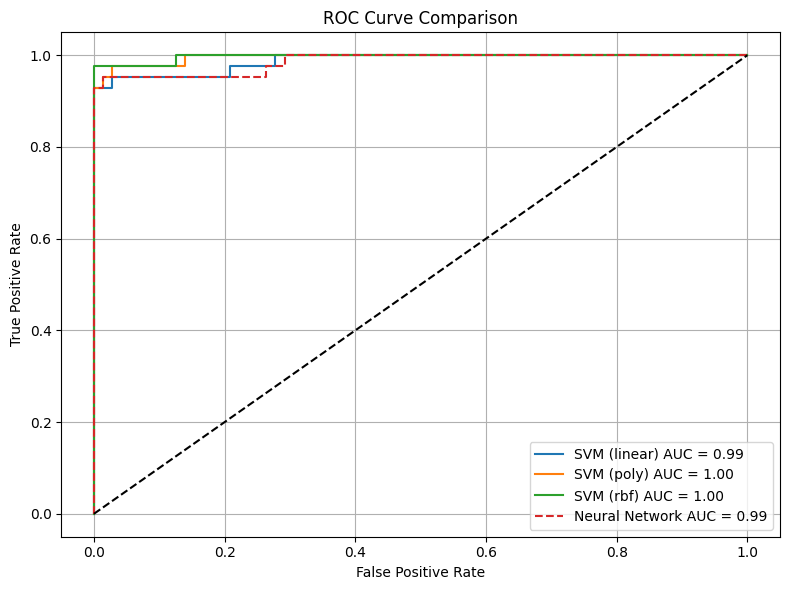

In [83]:
fpr_nn, tpr_nn, _ = roc_curve(y_test_b, y_pred_probs)
roc_auc_nn = auc(fpr_nn, tpr_nn)

plt.figure(figsize=(8, 6))

for kernel in kernels:
    svm = SVC(kernel=kernel, probability=True, random_state=42)
    svm.fit(X_train_scaled_b, y_train_b)
    svm_probs = svm.predict_proba(X_test_scaled_b)[:, 1]
    fpr_svm, tpr_svm, _ = roc_curve(y_test_b, svm_probs)
    roc_auc_svm = auc(fpr_svm, tpr_svm)
    plt.plot(fpr_svm, tpr_svm, label=f"SVM ({kernel}) AUC = {roc_auc_svm:.2f}")


plt.plot(fpr_nn, tpr_nn, label=f"Neural Network AUC = {roc_auc_nn:.2f}", linestyle='--')


plt.plot([0, 1], [0, 1], 'k--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()
